In [22]:
import sqlite3
from collections import defaultdict
import matplotlib.pyplot as plt

## Load Data from Database

In [23]:
def load_combinations(db_path='global.db', username=None):
    """
    Load all combinations from the database, optionally filtered by username.
    Returns combinations sorted by perUserRank (chronological order of discovery).
    """
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    if username:
        cursor.execute("""
            SELECT firstWord, secondWord, resultName, perUserRank
            FROM combinations
            WHERE username = ?
            ORDER BY perUserRank ASC
        """, (username,))
    else:
        # For global view, we need to find the earliest discovery of each combination
        # Group by the combination and take the minimum perUserRank
        cursor.execute("""
            SELECT firstWord, secondWord, resultName, MIN(perUserRank) as min_rank
            FROM combinations
            WHERE perUserRank IS NOT NULL
            GROUP BY firstWord, secondWord, resultName
            ORDER BY min_rank ASC
        """)
    
    combinations = []
    for row in cursor.fetchall():
        combinations.append({
            'from1': row[0],
            'from2': row[1],
            'to': row[2],
            'rank': row[3]
        })
    
    conn.close()
    return combinations

def load_material_ranks(db_path='global.db', username=None):
    """
    Load the rank of each material.
    Rank is the minimum perUserRank from combinations where the word is the result.
    Optionally filtered by username.
    """
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    if username:
        cursor.execute("""
            SELECT resultName, MIN(perUserRank) as min_rank
            FROM combinations
            WHERE perUserRank IS NOT NULL AND username = ?
            GROUP BY resultName
        """, (username,))
    else:
        cursor.execute("""
            SELECT resultName, MIN(perUserRank) as min_rank
            FROM combinations
            WHERE perUserRank IS NOT NULL
            GROUP BY resultName
        """)
    
    ranks = {}
    for row in cursor.fetchall():
        ranks[row[0]] = row[1]
    
    conn.close()
    return ranks

def get_top_users(db_path='global.db', n=4):
    """Get the top n users by number of combinations."""
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    cursor.execute("""
        SELECT username, COUNT(*) as combo_count
        FROM combinations
        GROUP BY username
        ORDER BY combo_count DESC
        LIMIT ?
    """, (n,))
    
    users = [(row[0], row[1]) for row in cursor.fetchall()]
    conn.close()
    return users

In [24]:
print("Loading combinations from database...")
combinations = load_combinations()
print(f"Loaded {len(combinations)} unique combinations")

print("\nLoading material ranks...")
material_ranks = load_material_ranks()
print(f"Loaded ranks for {len(material_ranks)} materials")

Loading combinations from database...
Loaded 11112 unique combinations

Loading material ranks...
Loaded ranks for 4844 materials


## Build Recipe Map

In [25]:
def build_recipe_map(combinations):
    """
    Build a map of result -> (ingredient1, ingredient2).
    
    IMPORTANT: Combinations must be sorted by perUserRank (chronologically).
    This ensures we only store the FIRST recipe for each result, which is the
    "shortest path" recipe that determined the material's rank.
    """
    recipe_map = {}
    for combo in combinations:
        result = combo['to']
        # Only store the first recipe we encounter (lowest rank = earliest discovery)
        if result not in recipe_map:
            recipe_map[result] = (combo['from1'], combo['from2'])
    return recipe_map

In [26]:
print("Building recipe map...")
recipe_map = build_recipe_map(combinations)
print(f"Built recipe map with {len(recipe_map)} results")

Building recipe map...
Built recipe map with 4844 results


## Count Transitive Dependencies (Shortest Path Only)

For each material, count how many other materials transitively depend on it **via the shortest recipe path**.

**Key insight:** A material's `perUserRank` is determined by the FIRST recipe that creates it (the "shortest path"). We should only count dependencies through this first recipe, not through all possible recipes.

**Algorithm:**
1. Process combinations in chronological order (sorted by perUserRank)
2. For each material, store only the FIRST recipe that creates it (the one that determined its rank)
3. Build dependency sets by tracing back through this "shortest recipe map"
4. Count how many materials depend on each material via their shortest paths

In [27]:
def count_dependencies(combinations, recipe_map):
    """
    For each material, count how many other materials transitively depend on it
    via the SHORTEST recipe path (the first recipe that creates each material).
    
    This matches how perUserRank is calculated - only counting dependencies
    through the recipe that first discovered each material.
    """
    
    base_materials = {'Fire', 'Water', 'Earth', 'Air'}
    
    # For each material, compute the set of materials it depends on (via shortest path)
    # We'll use the recipe_map which contains only the first recipe for each result
    dependencies = {}  # material -> set of materials it depends on
    
    # Initialize base materials (they depend on nothing)
    for base in base_materials:
        dependencies[base] = set()
    
    def get_dependencies(material, visited=None):
        """Recursively get all materials this material depends on via shortest path."""
        if visited is None:
            visited = set()
        
        if material in dependencies:
            return dependencies[material]
        
        if material in visited:
            # Cycle detected, return empty set
            return set()
        visited.add(material)
        
        if material in base_materials:
            dependencies[material] = set()
            return set()
        
        # Get the FIRST (shortest) recipe for this material
        if material not in recipe_map:
            # No recipe found, treat as base material
            dependencies[material] = set()
            return set()
        
        from1, from2 = recipe_map[material]
        
        # Get dependencies for both ingredients
        deps1 = get_dependencies(from1, visited.copy())
        deps2 = get_dependencies(from2, visited.copy())
        
        # This material depends on both ingredients and all their dependencies
        result_deps = set()
        result_deps.add(from1)
        result_deps.add(from2)
        result_deps.update(deps1)
        result_deps.update(deps2)
        
        dependencies[material] = result_deps
        return result_deps
    
    # Compute dependencies for all materials in the recipe map
    for material in recipe_map.keys():
        get_dependencies(material)
    
    # Now count how many materials depend on each material (via shortest path)
    material_usage = defaultdict(int)
    
    for result, deps in dependencies.items():
        # Skip base materials in the count (they're not "recipes")
        if result not in base_materials:
            # This material depends on all materials in deps via its shortest path
            for material in deps:
                material_usage[material] += 1
    
    return material_usage

In [28]:
print("Counting transitive dependencies...")
material_usage = count_dependencies(combinations, recipe_map)
print(f"Analyzed {len(material_usage)} materials")

Counting transitive dependencies...
Analyzed 3432 materials


## Materials by Number of Recipes That Depend on Them

In [29]:
# Sort by usage count (descending)
sorted_materials = sorted(material_usage.items(), key=lambda x: x[1], reverse=True)

print("=" * 100)
print("MATERIALS BY NUMBER OF RECIPES THAT DEPEND ON THEM")
print("=" * 100)
print(f"{'Material':<30} {'Rank':>10} {'Dependencies':>15} {'Dep/Rank Ratio':>15}")
print("-" * 100)

# Calculate ratios
ratios = []
for material, count in sorted_materials:
    rank = material_ranks.get(material)
    if rank and rank > 0:
        ratio = count / rank
        ratios.append(ratio)
        print(f"{material:<30} {rank:>10,} {count:>15,} {ratio:>15.2f}")
    else:
        print(f"{material:<30} {'N/A':>10} {count:>15,} {'N/A':>15}")

print("-" * 100)
print(f"Total materials analyzed: {len(sorted_materials)}")

MATERIALS BY NUMBER OF RECIPES THAT DEPEND ON THEM
Material                             Rank    Dependencies  Dep/Rank Ratio
----------------------------------------------------------------------------------------------------
Earth                                   2           4,150         2075.00
Air                                   N/A           4,032             N/A
Water                                  11           3,950          359.09
Planet                                  1           3,603         3603.00
Fire                                  N/A           3,452             N/A
Mud                                     1           3,445         3445.00
Dirt                                    1           3,363         3363.00
Atmosphere                              2           3,164         1582.00
Dust                                    2           3,098         1549.00
Oxygen                                  3           3,013         1004.33
Inspiration                       

## Average Dependencies-to-Rank Ratio

In [30]:
if ratios:
    avg_ratio = sum(ratios) / len(ratios)
    print(f"Average Dependencies-to-Rank Ratio: {avg_ratio:.4f}")
    print(f"Number of materials with valid ratios: {len(ratios)}")

Average Dependencies-to-Rank Ratio: 34.7342
Number of materials with valid ratios: 2250


## Top 10 Most Critical Materials (by dependency count)

In [31]:
print("=" * 100)
print("TOP 10 MOST CRITICAL MATERIALS (by dependency count)")
print("=" * 100)
for i, (material, count) in enumerate(sorted_materials[:10], 1):
    rank = material_ranks.get(material, 'N/A')
    rank_str = f"{rank:,}" if isinstance(rank, int) else rank
    print(f"{i:2d}. {material:<30} {count:>10,} recipes (Rank: {rank_str})")

TOP 10 MOST CRITICAL MATERIALS (by dependency count)
 1. Earth                               4,150 recipes (Rank: 2)
 2. Air                                 4,032 recipes (Rank: N/A)
 3. Water                               3,950 recipes (Rank: 11)
 4. Planet                              3,603 recipes (Rank: 1)
 5. Fire                                3,452 recipes (Rank: N/A)
 6. Mud                                 3,445 recipes (Rank: 1)
 7. Dirt                                3,363 recipes (Rank: 1)
 8. Atmosphere                          3,164 recipes (Rank: 2)
 9. Dust                                3,098 recipes (Rank: 2)
10. Oxygen                              3,013 recipes (Rank: 3)


## Top 20 Materials with Highest Dependency-to-Rank Ratio

These are materials that "punch above their weight" - many recipes depend on them relative to how early they appear in the game.

In [32]:
# Build list with ratios
materials_with_ratios = []
for material, count in material_usage.items():
    rank = material_ranks.get(material)
    if rank and rank > 0:
        ratio = count / rank
        materials_with_ratios.append((material, count, rank, ratio))

# Sort by ratio descending
materials_with_ratios.sort(key=lambda x: x[3], reverse=True)

print("=" * 100)
print("TOP 20 MATERIALS WITH HIGHEST DEPENDENCY-TO-RANK RATIO")
print("(Materials that punch above their weight - many depend on them relative to how early they appear)")
print("=" * 100)
print(f"{'Material':<30} {'Rank':>10} {'Dependencies':>15} {'Ratio':>15}")
print("-" * 100)
for i, (material, count, rank, ratio) in enumerate(materials_with_ratios[:20], 1):
    print(f"{i:2d}. {material:<27} {rank:>10,} {count:>15,} {ratio:>15.2f}")

TOP 20 MATERIALS WITH HIGHEST DEPENDENCY-TO-RANK RATIO
(Materials that punch above their weight - many depend on them relative to how early they appear)
Material                             Rank    Dependencies           Ratio
----------------------------------------------------------------------------------------------------
 1. Planet                               1           3,603         3603.00
 2. Mud                                  1           3,445         3445.00
 3. Dirt                                 1           3,363         3363.00
 4. Inspiration                          1           2,648         2648.00
 5. Breeze                               1           2,595         2595.00
 6. Steam                                1           2,577         2577.00
 7. Inferno                              1           2,512         2512.00
 8. Lava                                 1           2,450         2450.00
 9. Earth                                2           4,150         2075.

## Scatterplot: Rank vs Dependencies

Visualize the relationship between a material's rank (how early it appears) and how many recipes depend on it.

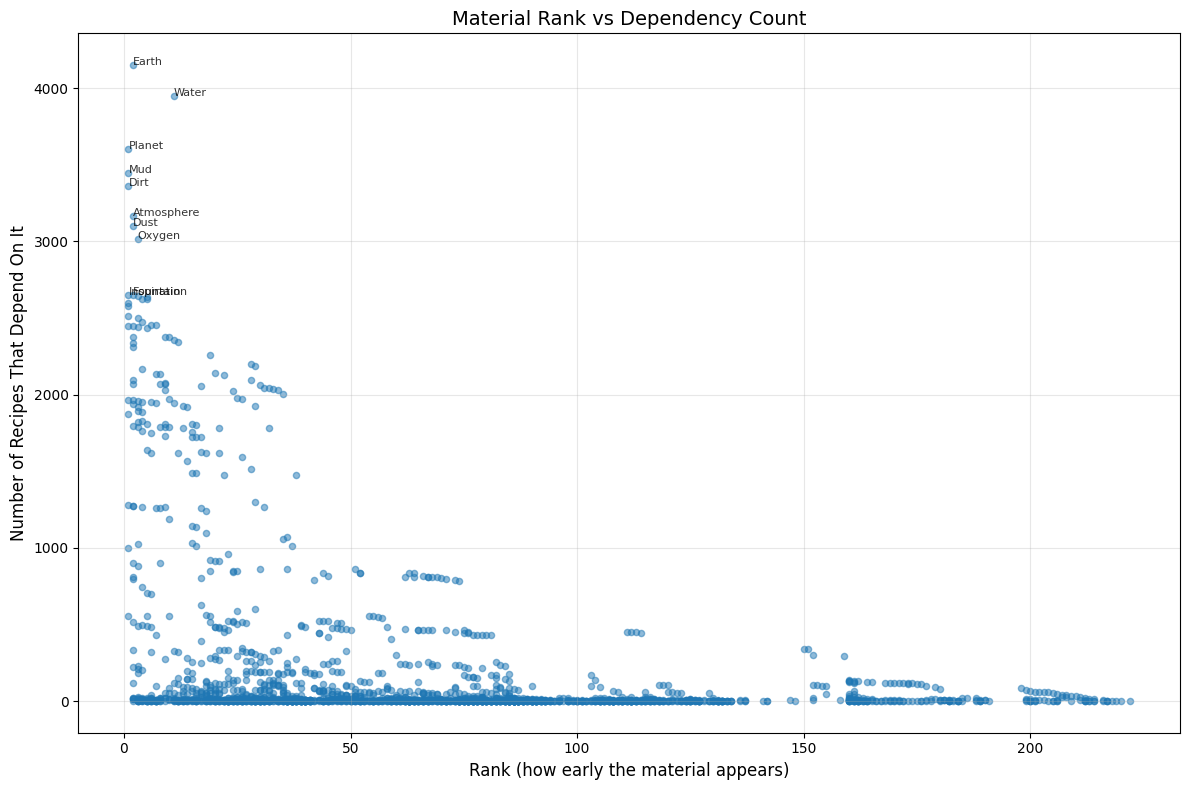

Plotted 2250 materials with valid ranks


In [33]:
# Prepare data for plotting
ranks_list = []
deps_list = []
names_list = []

for material, count in material_usage.items():
    rank = material_ranks.get(material)
    if rank and rank > 0:
        ranks_list.append(rank)
        deps_list.append(count)
        names_list.append(material)

# Create scatterplot
plt.figure(figsize=(12, 8))
plt.scatter(ranks_list, deps_list, alpha=0.5, s=20)

# Add labels for top materials (highest dependencies)
top_indices = sorted(range(len(deps_list)), key=lambda i: deps_list[i], reverse=True)[:10]
for i in top_indices:
    plt.annotate(names_list[i], (ranks_list[i], deps_list[i]), fontsize=8, alpha=0.8)

plt.xlabel('Rank (how early the material appears)', fontsize=12)
plt.ylabel('Number of Recipes That Depend On It', fontsize=12)
plt.title('Material Rank vs Dependency Count', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Plotted {len(ranks_list)} materials with valid ranks")

## Modeling the Upper Bound

The graph shows a downward-sloping triangle pattern, suggesting that the **maximum possible dependencies** decreases linearly with rank. Let's fit a linear model to the upper envelope (the "ceiling" of dependencies for each rank) and identify outliers that exceed expectations.

In [34]:
import numpy as np
from scipy.optimize import curve_fit

# Convert to numpy arrays
ranks_arr = np.array(ranks_list)
deps_arr = np.array(deps_list)

# Bucket size for smoothing
BUCKET_SIZE = 5

# Find the upper envelope - bucket ranks into groups of size N, find max in each bucket
# Create bucket assignments (0, 5, 10, 15, ...)
bucket_assignments = (ranks_arr // BUCKET_SIZE) * BUCKET_SIZE + BUCKET_SIZE // 2  # center of bucket

unique_buckets = np.unique(bucket_assignments)
max_deps_per_bucket = []
max_material_per_bucket = []  # Track which material has max deps in each bucket

for bucket in unique_buckets:
    bucket_mask = bucket_assignments == bucket
    bucket_deps = deps_arr[bucket_mask]
    max_idx_in_bucket = np.argmax(bucket_deps)
    
    # Find the actual index in the original arrays
    bucket_indices = np.where(bucket_mask)[0]
    max_material_idx = bucket_indices[max_idx_in_bucket]
    
    max_deps_per_bucket.append(bucket_deps.max())
    max_material_per_bucket.append(names_list[max_material_idx])

max_deps_per_bucket = np.array(max_deps_per_bucket)

print(f"Bucketed {len(np.unique(ranks_arr))} unique ranks into {len(unique_buckets)} buckets (size={BUCKET_SIZE})")

# Define different models to fit
def linear_model(x, a, b):
    return a + b * x

def exponential_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

def power_law(x, a, b, c):
    return a * (x + 1)**(-b) + c

def log_model(x, a, b, c):
    return a - b * np.log(x + 1) + c

# Fit each model to bucketed data
models = {}

# Linear fit
popt_linear, _ = curve_fit(linear_model, unique_buckets, max_deps_per_bucket)
models['Linear'] = {
    'func': linear_model,
    'params': popt_linear,
    'predict': lambda x: linear_model(x, *popt_linear)
}

# Exponential decay fit
try:
    popt_exp, _ = curve_fit(exponential_decay, unique_buckets, max_deps_per_bucket, 
                            p0=[3500, 0.01, 0], maxfev=10000)
    models['Exponential Decay'] = {
        'func': exponential_decay,
        'params': popt_exp,
        'predict': lambda x: exponential_decay(x, *popt_exp)
    }
except:
    print("Exponential decay fit failed")

# Power law fit
try:
    popt_power, _ = curve_fit(power_law, unique_buckets, max_deps_per_bucket,
                              p0=[3500, 0.5, 0], maxfev=10000)
    models['Power Law'] = {
        'func': power_law,
        'params': popt_power,
        'predict': lambda x: power_law(x, *popt_power)
    }
except:
    print("Power law fit failed")

# Log fit
try:
    popt_log, _ = curve_fit(log_model, unique_buckets, max_deps_per_bucket,
                            p0=[3500, 500, 0], maxfev=10000)
    models['Logarithmic'] = {
        'func': log_model,
        'params': popt_log,
        'predict': lambda x: log_model(x, *popt_log)
    }
except:
    print("Logarithmic fit failed")

# Calculate R² for each model
def calc_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

print("=" * 80)
print(f"MODEL COMPARISON (fitted to upper envelope, bucket size={BUCKET_SIZE})")
print("=" * 80)
print(f"{'Model':<20} {'R²':>12} {'Parameters'}")
print("-" * 80)

for name, model in models.items():
    y_pred = model['predict'](unique_buckets)
    r2 = calc_r2(max_deps_per_bucket, y_pred)
    model['r2'] = r2
    params_str = ', '.join([f'{p:.4f}' for p in model['params']])
    print(f"{name:<20} {r2:>12.6f} {params_str}")

# Find best model
best_model_name = max(models, key=lambda k: models[k]['r2'])
best_model = models[best_model_name]
print("-" * 80)
print(f"Best fit: {best_model_name} (R² = {best_model['r2']:.6f})")

Bucketed 202 unique ranks into 45 buckets (size=5)
MODEL COMPARISON (fitted to upper envelope, bucket size=5)
Model                          R² Parameters
--------------------------------------------------------------------------------
Linear                   0.586659 2032.4052, -12.0750
Exponential Decay        0.933497 4229.6044, 0.0289, 20.7414
Power Law                0.887899 12679.4114, 0.1294, -6518.4216
Logarithmic              0.879620 299231.8812, 1022.9613, -294013.9093
--------------------------------------------------------------------------------
Best fit: Exponential Decay (R² = 0.933497)


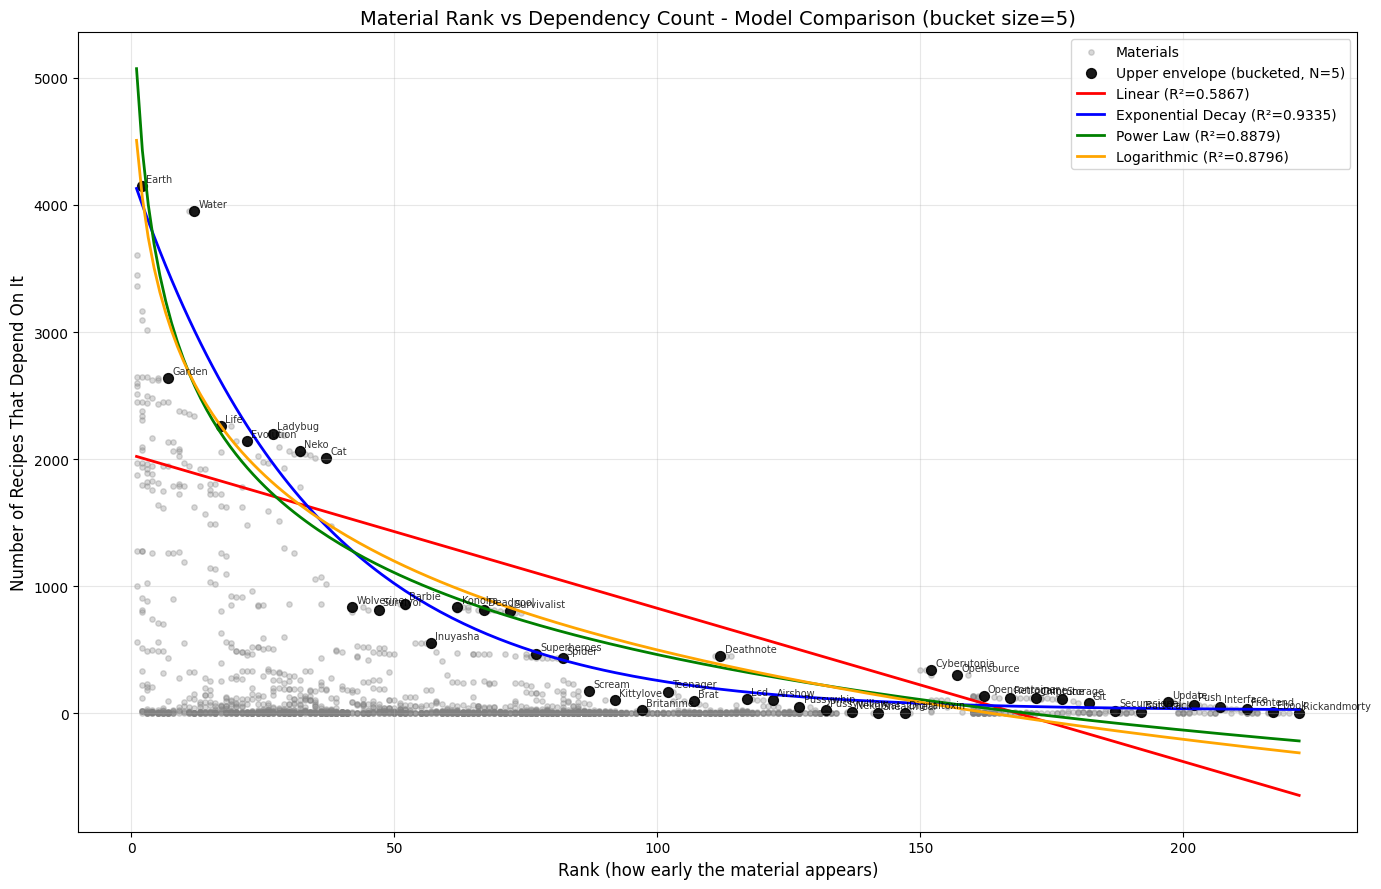

In [35]:
# Plot all models
plt.figure(figsize=(14, 9))
plt.scatter(ranks_arr, deps_arr, alpha=0.3, s=15, label='Materials', c='gray')
plt.scatter(unique_buckets, max_deps_per_bucket, c='black', s=50, alpha=0.9, 
            label=f'Upper envelope (bucketed, N={BUCKET_SIZE})')

# Label the max material in each bucket
for i, (bucket, deps, material) in enumerate(zip(unique_buckets, max_deps_per_bucket, max_material_per_bucket)):
    plt.annotate(material, (bucket, deps), fontsize=7, alpha=0.8,
                 xytext=(3, 3), textcoords='offset points')

x_line = np.linspace(1, max(unique_buckets), 200)

colors = ['red', 'blue', 'green', 'orange', 'purple']
for (name, model), color in zip(models.items(), colors):
    y_line = model['predict'](x_line)
    plt.plot(x_line, y_line, color=color, linewidth=2, 
             label=f"{name} (R²={model['r2']:.4f})")

plt.xlabel('Rank (how early the material appears)', fontsize=12)
plt.ylabel('Number of Recipes That Depend On It', fontsize=12)
plt.title(f'Material Rank vs Dependency Count - Model Comparison (bucket size={BUCKET_SIZE})', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Using Exponential Decay model for outlier detection


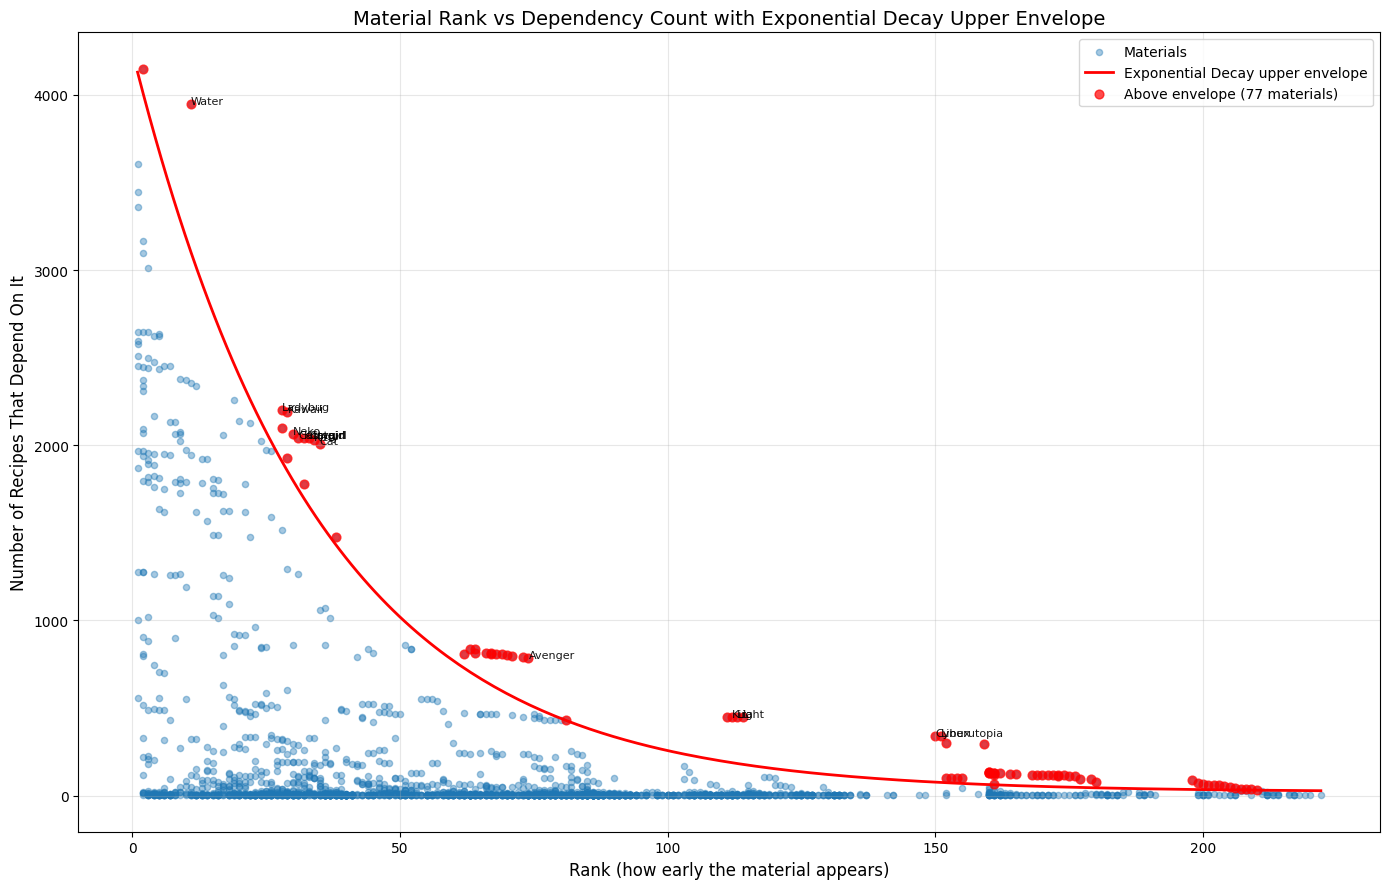

In [36]:
# Use the best model for outlier detection
print(f"\nUsing {best_model_name} model for outlier detection")

# Calculate expected max and residuals using best model
expected_max = best_model['predict'](ranks_arr)
residuals = deps_arr - expected_max

# Plot with the best fit
plt.figure(figsize=(14, 9))
plt.scatter(ranks_arr, deps_arr, alpha=0.4, s=20, label='Materials')

# Plot the best model fit
x_line = np.linspace(1, max(ranks_arr), 200)
y_line = best_model['predict'](x_line)
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'{best_model_name} upper envelope')

# Highlight outliers (materials above the line)
outlier_threshold = 0
outlier_mask = residuals > outlier_threshold

plt.scatter(ranks_arr[outlier_mask], deps_arr[outlier_mask], 
            c='red', s=40, alpha=0.7, label=f'Above envelope ({outlier_mask.sum()} materials)')

# Label the most extreme outliers
outlier_indices = np.where(outlier_mask)[0]
sorted_outlier_indices = sorted(outlier_indices, key=lambda i: residuals[i], reverse=True)[:15]
for i in sorted_outlier_indices:
    plt.annotate(names_list[i], (ranks_arr[i], deps_arr[i]), fontsize=8, alpha=0.9)

plt.xlabel('Rank (how early the material appears)', fontsize=12)
plt.ylabel('Number of Recipes That Depend On It', fontsize=12)
plt.title(f'Material Rank vs Dependency Count with {best_model_name} Upper Envelope', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Major Outliers: Materials with Unusually High Dependencies for Their Rank

These materials have more recipes depending on them than expected based on the upper envelope model. They "punch above their weight" for how late they appear in the game.

In [37]:
# Build a list of outliers with their stats (using best model)
outliers_data = []
for i in range(len(names_list)):
    rank = ranks_arr[i]
    deps = deps_arr[i]
    expected = best_model['predict'](np.array([rank]))[0]
    residual = deps - expected
    if residual > 0:  # Above the upper envelope
        outliers_data.append({
            'name': names_list[i],
            'rank': rank,
            'dependencies': deps,
            'expected_max': expected,
            'excess': residual,
            'excess_pct': (residual / expected) * 100 if expected > 0 else float('inf')
        })

# Sort by excess (how much above expected)
outliers_data.sort(key=lambda x: x['excess'], reverse=True)

print("=" * 110)
print(f"MAJOR OUTLIERS: Materials with Dependencies ABOVE the {best_model_name} Upper Envelope")
print("=" * 110)
print(f"{'Material':<25} {'Rank':>8} {'Actual Deps':>12} {'Expected Max':>14} {'Excess':>10} {'Excess %':>10}")
print("-" * 110)

for item in outliers_data[:30]:
    print(f"{item['name']:<25} {item['rank']:>8} {item['dependencies']:>12,} {item['expected_max']:>14,.0f} {item['excess']:>10,.0f} {item['excess_pct']:>9.1f}%")

print("-" * 110)
print(f"Total materials above upper envelope: {len(outliers_data)}")
print(f"\nThese materials have unusually high dependency counts for how late they appear in the game.")

MAJOR OUTLIERS: Materials with Dependencies ABOVE the Exponential Decay Upper Envelope
Material                      Rank  Actual Deps   Expected Max     Excess   Excess %
--------------------------------------------------------------------------------------------------------------
Water                           11        3,950          3,100        850      27.4%
Cat                             35        2,007          1,561        446      28.6%
Kitty                           34        2,030          1,606        424      26.4%
Catgirl                         33        2,039          1,653        386      23.4%
Kittygirl                       32        2,040          1,700        340      20.0%
Kawaii                          29        2,187          1,852        335      18.1%
Ladybug                         28        2,200          1,906        294      15.4%
Catmaid                         31        2,043          1,750        293      16.8%
L                              114   

In [38]:
# Focus on the most interesting outliers - those with high rank but still high dependencies
# Filter to materials with rank > 50 that still have high excess
late_outliers = [o for o in outliers_data if o['rank'] > 50]
late_outliers.sort(key=lambda x: x['excess'], reverse=True)

print("=" * 110)
print("LATE-GAME OUTLIERS: Materials with rank > 50 that still have high dependencies")
print("=" * 110)
print(f"{'Material':<25} {'Rank':>8} {'Actual Deps':>12} {'Expected Max':>14} {'Excess':>10} {'Excess %':>10}")
print("-" * 110)

for item in late_outliers[:20]:
    print(f"{item['name']:<25} {item['rank']:>8} {item['dependencies']:>12,} {item['expected_max']:>14,.0f} {item['excess']:>10,.0f} {item['excess_pct']:>9.1f}%")

print("-" * 110)
print(f"Total late-game outliers (rank > 50): {len(late_outliers)}")

LATE-GAME OUTLIERS: Materials with rank > 50 that still have high dependencies
Material                      Rank  Actual Deps   Expected Max     Excess   Excess %
--------------------------------------------------------------------------------------------------------------
L                              114          447            178        269     150.7%
Avenger                         74          786            521        265      51.0%
Light                          113          448            183        265     144.9%
Linux                          151          338             75        263     351.2%
Cyberutopia                    150          339             76        263     343.2%
Kira                           112          449            188        261     139.3%
Deathnote                      111          450            193        257     133.7%
Superhero                       73          791            535        256      47.8%
Opensource                     159          2

## Per-User Outlier Analysis

Analyze the major outliers for each of the top 4 users by examining their individual subgraphs.

In [39]:
# Get top 4 users
top_users = get_top_users(n=4)
print("Top 4 users by combination count:")
for username, count in top_users:
    print(f"  {username}: {count:,} combinations")

Top 4 users by combination count:
  isabel: 4,916 combinations
  tim: 2,179 combinations
  ace: 1,378 combinations
  izzy: 1,191 combinations


In [40]:
def analyze_user_outliers(username, top_n=15):
    """Analyze dependency outliers for a specific user's subgraph."""
    
    # Load user-specific data
    user_combinations = load_combinations(username=username)
    user_ranks = load_material_ranks(username=username)
    
    if len(user_combinations) == 0:
        print(f"No combinations found for user {username}")
        return None
    
    # Build recipe map and count dependencies
    user_recipe_map = build_recipe_map(user_combinations)
    user_material_usage = count_dependencies(user_combinations, user_recipe_map)
    
    # Prepare data for analysis
    user_ranks_list = []
    user_deps_list = []
    user_names_list = []
    
    for material, count in user_material_usage.items():
        rank = user_ranks.get(material)
        if rank and rank > 0:
            user_ranks_list.append(rank)
            user_deps_list.append(count)
            user_names_list.append(material)
    
    if len(user_ranks_list) < 10:
        print(f"Not enough data points for user {username} ({len(user_ranks_list)} materials with valid ranks)")
        return None
    
    user_ranks_arr = np.array(user_ranks_list)
    user_deps_arr = np.array(user_deps_list)
    
    # Find upper envelope for this user (with bucketing)
    user_unique_ranks_raw = np.unique(user_ranks_arr)
    user_max_deps_raw = []
    for r in user_unique_ranks_raw:
        user_max_deps_raw.append(user_deps_arr[user_ranks_arr == r].max())
    user_max_deps_raw = np.array(user_max_deps_raw)
    
    # Bucket the ranks for smoother fitting and track max materials
    user_bucket_centers = []
    user_max_deps_bucketed = []
    user_max_materials_bucketed = []  # Track max material name per bucket
    
    for bucket_start in range(int(min(user_unique_ranks_raw)), int(max(user_unique_ranks_raw)) + 1, BUCKET_SIZE):
        bucket_end = bucket_start + BUCKET_SIZE
        # Find materials in this bucket range (using original data, not unique ranks)
        bucket_mask = (user_ranks_arr >= bucket_start) & (user_ranks_arr < bucket_end)
        if bucket_mask.any():
            bucket_deps = user_deps_arr[bucket_mask]
            max_idx_in_bucket = np.argmax(bucket_deps)
            bucket_indices = np.where(bucket_mask)[0]
            max_material_idx = bucket_indices[max_idx_in_bucket]
            
            user_bucket_centers.append(bucket_start + BUCKET_SIZE / 2)
            user_max_deps_bucketed.append(bucket_deps.max())
            user_max_materials_bucketed.append(user_names_list[max_material_idx])
    
    user_bucket_centers = np.array(user_bucket_centers)
    user_max_deps_bucketed = np.array(user_max_deps_bucketed)
    
    # Fit exponential decay model to bucketed data
    try:
        popt, _ = curve_fit(exponential_decay, user_bucket_centers, user_max_deps_bucketed,
                           p0=[max(user_max_deps_bucketed), 0.01, 0], maxfev=10000)
        user_model = lambda x, p=popt: exponential_decay(x, *p)
        model_name = "Exponential Decay"
    except:
        # Fall back to linear on bucketed data
        popt, _ = curve_fit(linear_model, user_bucket_centers, user_max_deps_bucketed)
        user_model = lambda x, p=popt: linear_model(x, *p)
        model_name = "Linear"
    
    # Calculate residuals
    user_expected = user_model(user_ranks_arr)
    user_residuals = user_deps_arr - user_expected
    
    # Find outliers
    user_outliers = []
    for i in range(len(user_names_list)):
        rank = user_ranks_arr[i]
        deps = user_deps_arr[i]
        expected = user_expected[i]
        residual = user_residuals[i]
        if residual > 0:
            user_outliers.append({
                'name': user_names_list[i],
                'rank': rank,
                'dependencies': deps,
                'expected_max': expected,
                'excess': residual,
                'excess_pct': (residual / expected) * 100 if expected > 0 else 0
            })
    
    user_outliers.sort(key=lambda x: x['excess'], reverse=True)
    
    return {
        'username': username,
        'total_combinations': len(user_combinations),
        'materials_analyzed': len(user_names_list),
        'model': model_name,
        'model_func': user_model,
        'outliers': user_outliers[:top_n],
        'ranks_arr': user_ranks_arr,
        'deps_arr': user_deps_arr,
        'names_list': user_names_list,
        'unique_ranks': user_unique_ranks_raw,
        'max_deps': user_max_deps_raw,
        'bucket_centers': user_bucket_centers,
        'max_deps_bucketed': user_max_deps_bucketed,
        'max_materials_bucketed': user_max_materials_bucketed,
        'residuals': user_residuals
    }

# Analyze each top user
user_analyses = {}
for username, combo_count in top_users:
    print(f"\nAnalyzing {username}...")
    result = analyze_user_outliers(username)
    if result:
        user_analyses[username] = result


Analyzing isabel...

Analyzing tim...

Analyzing ace...

Analyzing izzy...


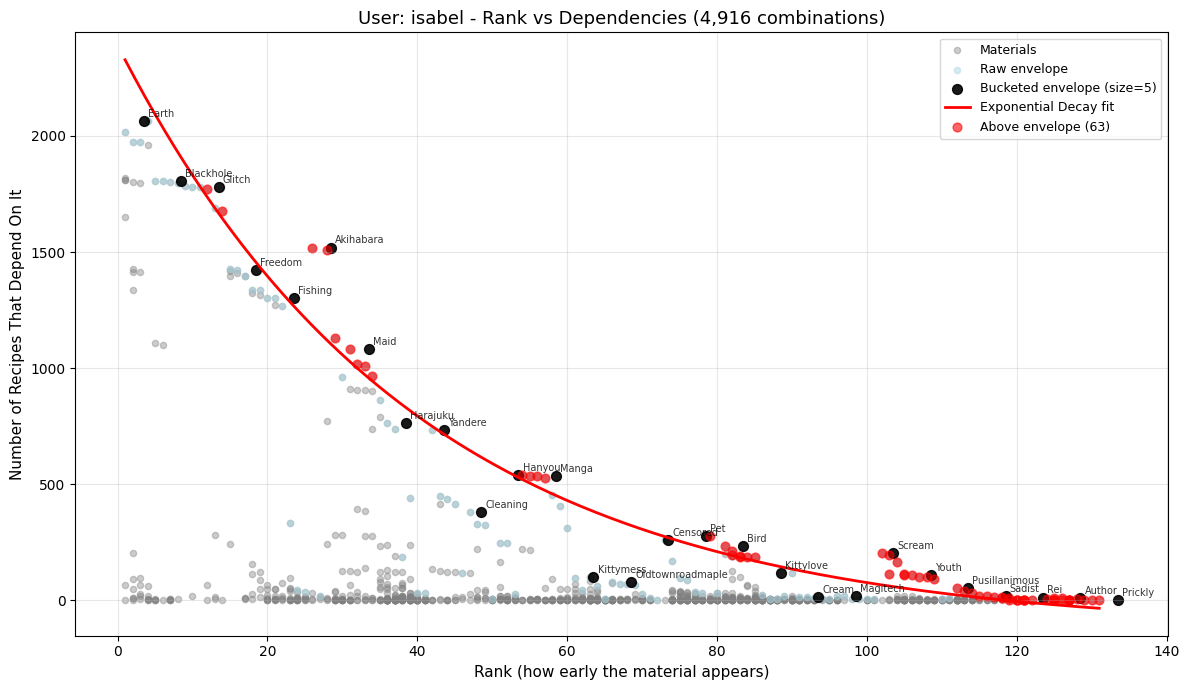

MAJOR OUTLIERS FOR USER: isabel
Total combinations: 4,916 | Materials analyzed: 1,139 | Model: Exponential Decay
Material                           Rank  Actual Deps   Expected Max     Excess   Excess %
--------------------------------------------------------------------------------------------------------------
Moe                                  28        1,511          1,119        392      35.1%
Akihabara                            26        1,519          1,183        336      28.4%
Scream                              102          203             67        136     204.9%
Teenager                            103          196             62        134     217.4%
Children                            104          164             57        107     187.5%
Youth                               106          108             48         60     125.0%
Phobia                              108           99             39         60     151.4%
Oldtownroadkids                     105          112    

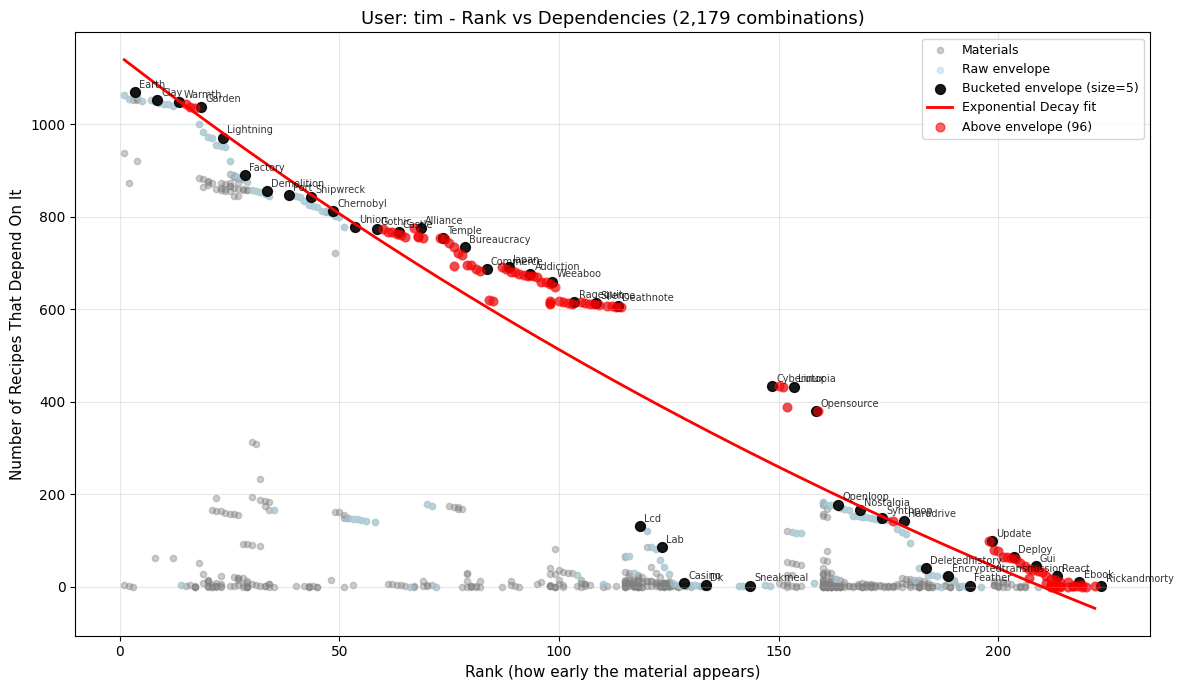

MAJOR OUTLIERS FOR USER: tim
Total combinations: 2,179 | Materials analyzed: 703 | Model: Exponential Decay
Material                           Rank  Actual Deps   Expected Max     Excess   Excess %
--------------------------------------------------------------------------------------------------------------
Linux                               151          433            255        178      70.0%
Cyberutopia                         150          434            259        175      67.3%
L                                   114          605            438        167      38.1%
Light                               113          606            443        163      36.7%
Opensource                          159          380            218        162      74.6%
Kira                                112          607            449        158      35.3%
Deathnote                           111          608            454        154      33.9%
Antihero                            109          610         

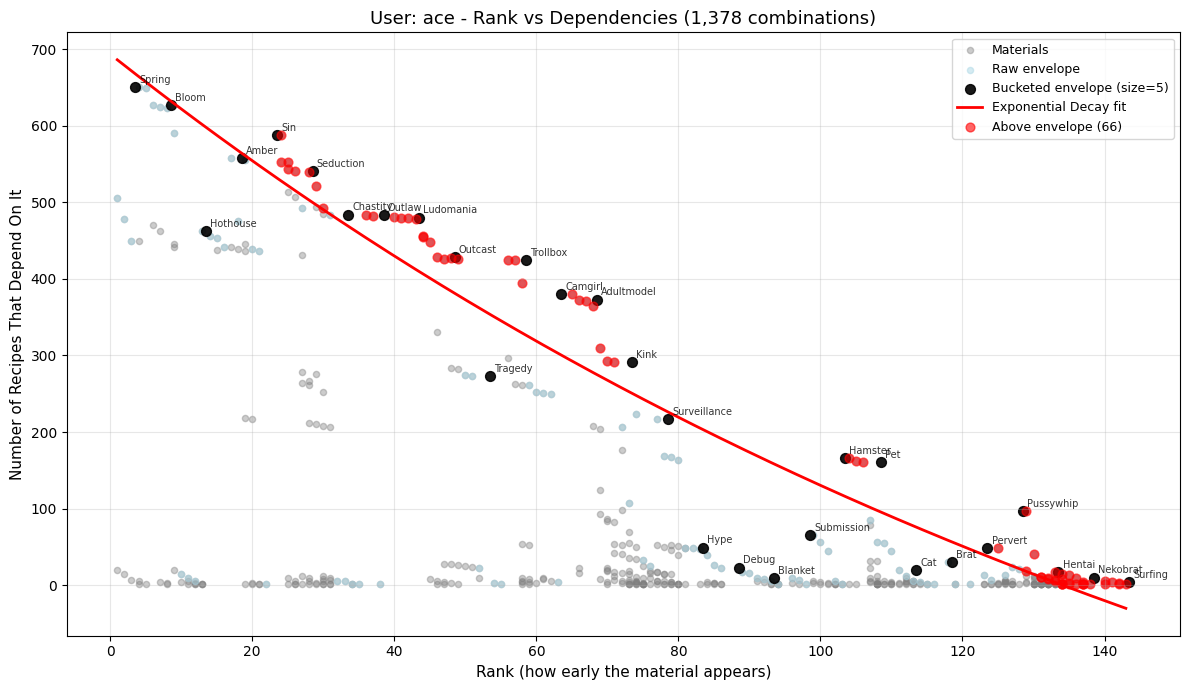

MAJOR OUTLIERS FOR USER: ace
Total combinations: 1,378 | Materials analyzed: 464 | Model: Exponential Decay
Material                           Rank  Actual Deps   Expected Max     Excess   Excess %
--------------------------------------------------------------------------------------------------------------
Internet                             57          424            335         89      26.7%
Pornstar                             67          371            283         88      31.3%
Camgirl                              65          380            293         87      29.8%
Orgy                                 68          364            278         86      31.1%
Adultmodel                           66          373            288         85      29.6%
Trollbox                             56          425            340         85      25.0%
Pussywhip                           129           97             18         79     441.5%
Porn                                 58          395         

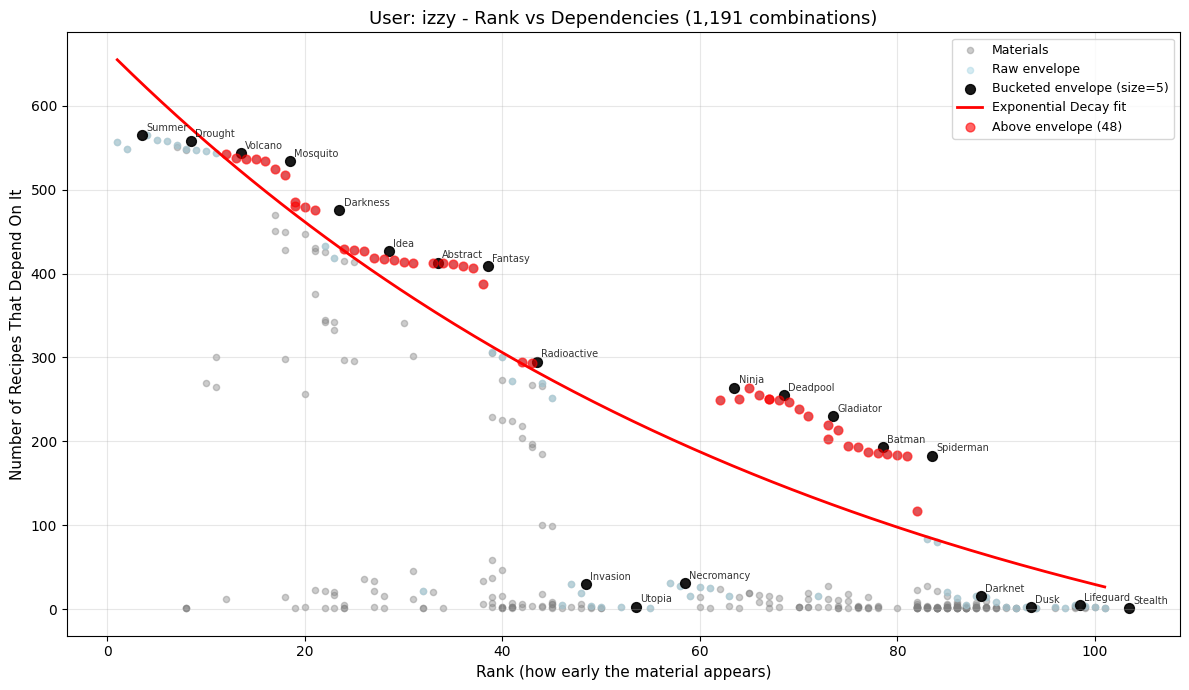

MAJOR OUTLIERS FOR USER: izzy
Total combinations: 1,191 | Materials analyzed: 354 | Model: Exponential Decay
Material                           Rank  Actual Deps   Expected Max     Excess   Excess %
--------------------------------------------------------------------------------------------------------------
Conspiracy                           69          247            144        103      71.5%
Ninja                                65          264            163        101      62.3%
Cable                                68          249            149        100      67.6%
Survivalist                          70          238            140         98      70.6%
Xforce                               67          251            153         98      63.8%
Deadpool                             66          255            158         97      61.5%
Hellspawn                            67          250            153         97      63.2%
Gladiator                            71          230        

In [41]:
# Display graph and outliers for each user
for username, analysis in user_analyses.items():
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Scatter plot of all materials
    ax.scatter(analysis['ranks_arr'], analysis['deps_arr'], alpha=0.4, s=20, label='Materials', c='gray')
    
    # Plot upper envelope points (raw and bucketed)
    ax.scatter(analysis['unique_ranks'], analysis['max_deps'], c='lightblue', s=20, alpha=0.5, label='Raw envelope')
    ax.scatter(analysis['bucket_centers'], analysis['max_deps_bucketed'], c='black', s=50, alpha=0.9, 
               label=f'Bucketed envelope (size={BUCKET_SIZE})')
    
    # Label the max material in each bucket
    for bucket, deps, material in zip(analysis['bucket_centers'], analysis['max_deps_bucketed'], analysis['max_materials_bucketed']):
        ax.annotate(material, (bucket, deps), fontsize=7, alpha=0.8,
                    xytext=(3, 3), textcoords='offset points')
    
    # Plot the fitted model
    x_line = np.linspace(1, max(analysis['ranks_arr']), 200)
    y_line = analysis['model_func'](x_line)
    ax.plot(x_line, y_line, 'r-', linewidth=2, label=f"{analysis['model']} fit")
    
    # Highlight outliers
    outlier_mask = analysis['residuals'] > 0
    ax.scatter(analysis['ranks_arr'][outlier_mask], analysis['deps_arr'][outlier_mask], 
               c='red', s=40, alpha=0.6, label=f'Above envelope ({outlier_mask.sum()})')
    
    ax.set_xlabel('Rank (how early the material appears)', fontsize=11)
    ax.set_ylabel('Number of Recipes That Depend On It', fontsize=11)
    ax.set_title(f"User: {username} - Rank vs Dependencies ({analysis['total_combinations']:,} combinations)", fontsize=13)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print outliers table
    print("=" * 110)
    print(f"MAJOR OUTLIERS FOR USER: {username}")
    print(f"Total combinations: {analysis['total_combinations']:,} | Materials analyzed: {analysis['materials_analyzed']:,} | Model: {analysis['model']}")
    print("=" * 110)
    print(f"{'Material':<30} {'Rank':>8} {'Actual Deps':>12} {'Expected Max':>14} {'Excess':>10} {'Excess %':>10}")
    print("-" * 110)
    
    for item in analysis['outliers']:
        print(f"{item['name']:<30} {item['rank']:>8} {item['dependencies']:>12,} {item['expected_max']:>14,.0f} {item['excess']:>10,.0f} {item['excess_pct']:>9.1f}%")
    
    print("-" * 110)
    print()

In [42]:
# Find the first combination that resulted in "L"
conn = sqlite3.connect('global.db')
cursor = conn.cursor()

cursor.execute("""
    SELECT *
    FROM combinations
    WHERE resultName = 'L'
    ORDER BY id ASC
    LIMIT 5
""")

print("First combinations that resulted in 'L':")
print("=" * 80)
print(f"{'id':<20} {'First Word':<20} {'Second Word':<20} {'Rank':>8} {'Username':<20}")
print("-" * 80)
for row in cursor.fetchall():
    print(row)

conn.close()

First combinations that resulted in 'L':
id                   First Word           Second Word              Rank Username            
--------------------------------------------------------------------------------
(4508, 'Light', 'Light yagami', 'L', '🕵', 'tim', '2026-01-10T00:27:46.283234', 114, 1)
(4800, 'Deathnote squad', 'Akihabara', 'L', '🕵', 'tim', '2026-01-10T01:03:52.069477', 124, 0)
